In [1]:
import numpy as np
import matplotlib.pyplot as plt

def thermal_simulation(current_profile, time_profile, R_internal=0.01, hA=0.1, 
                       m=0.045, Cp=900, T_amb=25):
    """
    Simulates battery temperature over time given current profile.
    """
    T = np.zeros_like(time_profile, dtype=float)
    T[0] = T_amb
    dt = np.mean(np.diff(time_profile))
    
    for t in range(1, len(time_profile)):
        Q_gen = (current_profile[t]**2) * R_internal
        Q_loss = hA * (T[t-1] - T_amb)
        dT = (Q_gen - Q_loss) * dt / (m * Cp)
        T[t] = T[t-1] + dT
    return T


In [2]:
# Time (600 seconds = 10 minutes, dt = 1s)
time_profile = np.arange(0, 600, 1)

# Different load cases (currents in A)
scenarios = {
    "Low Load (10A)": np.ones_like(time_profile) * 10,
    "Medium Load (30A)": np.ones_like(time_profile) * 30,
    "High Load (50A)": np.ones_like(time_profile) * 50,
    "Pulsed Load": np.where((time_profile % 60) < 30, 40, 0)  # 40A on/off every 30s
}

# Cooling conditions (hA values)
cooling_cases = [0.05, 0.1, 0.2]  # weak, normal, strong cooling


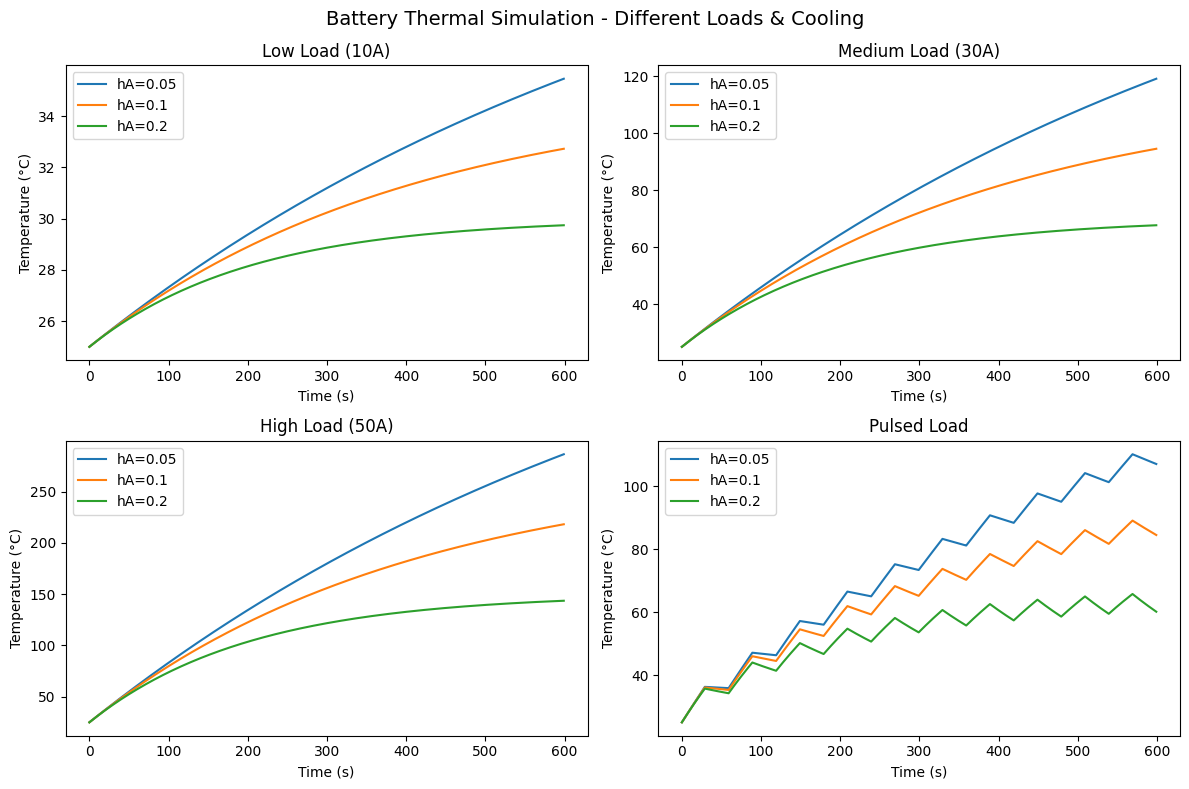

In [3]:
plt.figure(figsize=(12,8))

for i, (label, current) in enumerate(scenarios.items()):
    plt.subplot(2,2,i+1)
    for hA in cooling_cases:
        T = thermal_simulation(current, time_profile, R_internal=0.01, hA=hA)
        plt.plot(time_profile, T, label=f"hA={hA}")
    plt.title(label)
    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (°C)")
    plt.legend()

plt.suptitle("Battery Thermal Simulation - Different Loads & Cooling", fontsize=14)
plt.tight_layout()
plt.show()


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def thermal_simulation(current_profile, time_profile, R_internal=0.01, hA=0.1, 
                       m=0.045, Cp=900, T_amb=25):
    """
    Simulates battery temperature over time given current profile.
    """
    T = np.zeros_like(time_profile, dtype=float)
    T[0] = T_amb
    dt = np.mean(np.diff(time_profile))
    
    for t in range(1, len(time_profile)):
        Q_gen = (current_profile[t]**2) * R_internal
        Q_loss = hA * (T[t-1] - T_amb)
        dT = (Q_gen - Q_loss) * dt / (m * Cp)
        T[t] = T[t-1] + dT
    return T


In [5]:
# Example: load cycle 10
cycle_path = "../data/processed/B0005_cycle_10.csv"
df_cycle = pd.read_csv(cycle_path)

time_profile = df_cycle["time_s"].values
current_profile = df_cycle["current_A"].values
T_amb = df_cycle["temp_C"].iloc[0]  # start from measured ambient temp


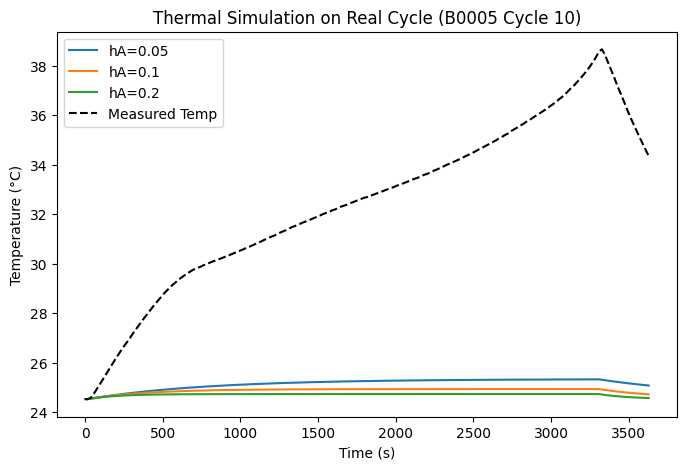

In [6]:
cooling_cases = [0.05, 0.1, 0.2]  # weak, medium, strong cooling
plt.figure(figsize=(8,5))

for hA in cooling_cases:
    T_sim = thermal_simulation(current_profile, time_profile, 
                               R_internal=0.01, hA=hA, T_amb=T_amb)
    plt.plot(time_profile, T_sim, label=f"hA={hA}")

# Plot measured temperature for comparison
plt.plot(time_profile, df_cycle["temp_C"].values, 'k--', label="Measured Temp")

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Thermal Simulation on Real Cycle (B0005 Cycle 10)")
plt.legend()
plt.show()


Selected cycles (early, mid, late): [2, 294, 614]


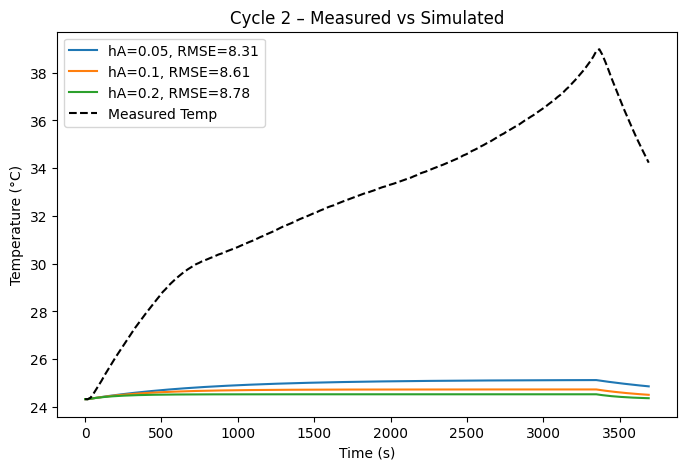

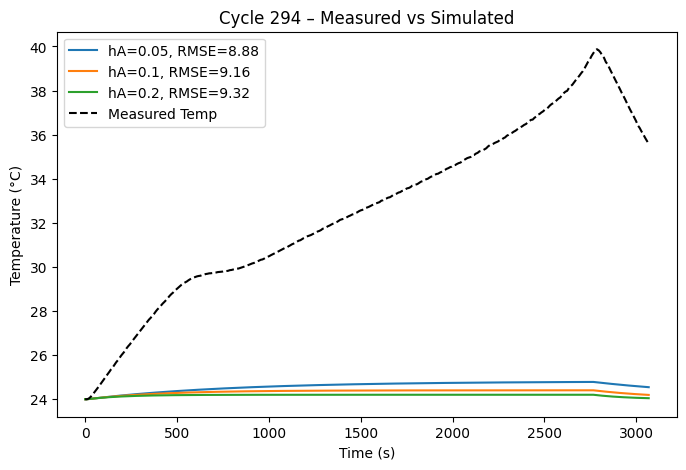

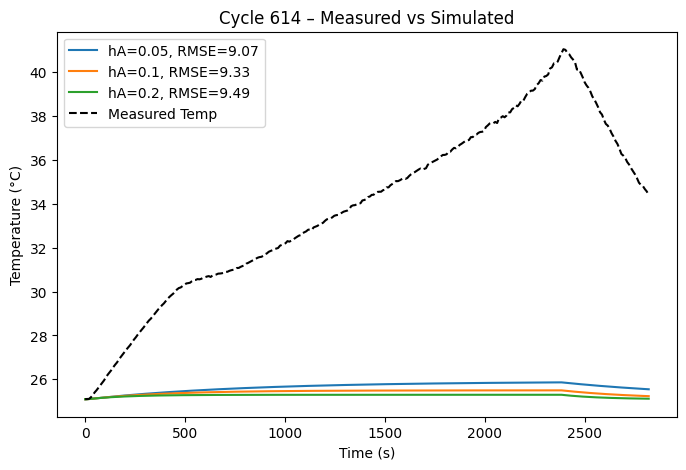

In [11]:
from sklearn.metrics import mean_squared_error
import numpy as np

def run_cycle_sim(cycle_num, hA_values=[0.05, 0.1, 0.2], R_internal=0.01):
    path = f"../data/processed/B0005_cycle_{cycle_num}.csv"
    if not os.path.exists(path):
        print(f"Cycle {cycle_num} not found!")
        return None
    
    df = pd.read_csv(path)
    time_profile = df["time_s"].values
    current_profile = df["current_A"].values
    T_meas = df["temp_C"].values
    T_amb = T_meas[0]

    plt.figure(figsize=(8,5))
    
    for hA in hA_values:
        T_sim = thermal_simulation(current_profile, time_profile, 
                                   R_internal=R_internal, hA=hA, T_amb=T_amb)
        rmse = np.sqrt(mean_squared_error(T_meas, T_sim))
        plt.plot(time_profile, T_sim, label=f"hA={hA}, RMSE={rmse:.2f}")
    
    plt.plot(time_profile, T_meas, 'k--', label="Measured Temp")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (°C)")
    plt.title(f"Cycle {cycle_num} – Measured vs Simulated")
    plt.legend()
    plt.show()
# Get the list of available discharge cycles
import glob

files = glob.glob("../data/processed/B0005_cycle_*.csv")
cycle_nums = sorted([int(f.split("_")[-1].split(".")[0]) for f in files])

# Pick early, mid, late from available discharge cycles
early = cycle_nums[0]                 # first discharge
mid = cycle_nums[len(cycle_nums)//2]  # middle discharge
late = cycle_nums[-1]                 # last discharge

selected_cycles = [early, mid, late]
print("Selected cycles (early, mid, late):", selected_cycles)

for c in selected_cycles:
    run_cycle_sim(c)


In [12]:
rmse_results = []

# Choose a fixed cooling value for evaluation (say hA=0.1 W/K)
hA_eval = 0.1
R_eval = 0.01

for c in cycle_nums:
    path = f"../data/processed/B0005_cycle_{c}.csv"
    df = pd.read_csv(path)
    
    time_profile = df["time_s"].values
    current_profile = df["current_A"].values
    T_meas = df["temp_C"].values
    T_amb = T_meas[0]

    T_sim = thermal_simulation(current_profile, time_profile, 
                               R_internal=R_eval, hA=hA_eval, T_amb=T_amb)
    
    rmse = np.sqrt(mean_squared_error(T_meas, T_sim))
    rmse_results.append({"cycle_num": c, "rmse": rmse})

df_rmse = pd.DataFrame(rmse_results)


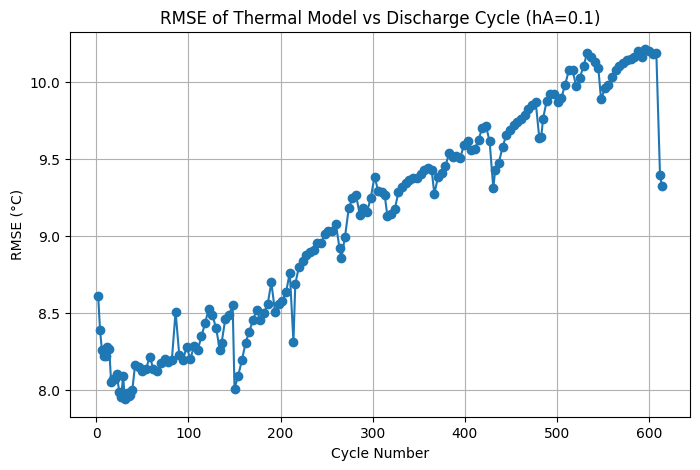

In [13]:
plt.figure(figsize=(8,5))
plt.plot(df_rmse["cycle_num"], df_rmse["rmse"], marker="o", linestyle="-")
plt.xlabel("Cycle Number")
plt.ylabel("RMSE (°C)")
plt.title(f"RMSE of Thermal Model vs Discharge Cycle (hA={hA_eval})")
plt.grid(True)
plt.show()
